In [1]:
%reload_ext autoreload
%autoreload 2

import c2qa
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RGate
from qiskit.converters import circuit_to_gate
from qutip import *
from qiskit.circuit import Parameter
from qiskit.circuit.library import UnitaryGate
from custom_gates import shors,state_generation
from qiskit.visualization import plot_histogram
from scipy.stats.contingency import margins

In [2]:
cutoff = 2**5
qmr1 = c2qa.QumodeRegister(num_qumodes=3, num_qubits_per_qumode=int(np.ceil(np.log2(cutoff))),name = 'qumode')
qbr = QuantumRegister(1)
cr = ClassicalRegister(1)

## Q displacement by +1

In [ ]:
circuit = c2qa.CVCircuit(qmr1,qbr,cr)
circuit.cv_sq(-np.log(0.202),qmr1[0])  # qumode 0 in squeezed vaccum at x=0

Q_displace = shors.Q_displacement_plus1(cutoff)
gate1 =UnitaryGate(Q_displace.full(), label='Q+1')
circuit.append(gate1, qmr1[0])

circuit.barrier()
stateop, result, _ = c2qa.util.simulate(circuit,shots = 128)
# circuit.draw('mpl')

In [5]:
qumode0 = shors.trace_out_qumode_index(circuit,stateop,qmr1,qbr,'0')

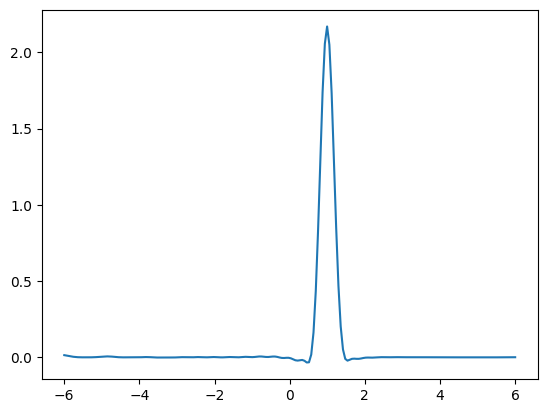

In [6]:
x_dist,xaxis = shors.position_plotting(qumode0,cutoff)

display(plt.plot(xaxis,x_dist))

## LSB Extract

In [10]:
circuit = c2qa.CVCircuit(qmr1,qbr,cr)
circuit.cv_sq(-np.log(0.202),qmr1[0])  # qumode 0 in squeezed vaccum at x=0

Q_displace = shors.Q_displacement_plus1(cutoff)
gate1 =UnitaryGate(Q_displace.full(), label='Q+1')
circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=1

circuit.barrier()

LSB_extract = shors.extractLSB(cutoff)
gate1 =UnitaryGate(LSB_extract.full(), label='LSB')
circuit.append(gate1, qmr1[0]+qbr[:])

circuit.measure(qbr[0],cr)

stateop, result, _ = c2qa.util.simulate(circuit,shots = 128)

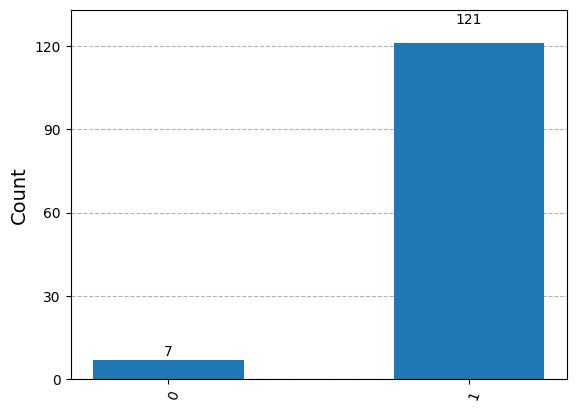

In [11]:
plot_histogram(result.get_counts())